# Modelos Mixtos — Combinaciones Conv1D, LSTM y GRU

Este notebook explora combinaciones de capas **convolucionales** (Conv1D) y **recurrentes** (LSTM, GRU) para la configuración fija:

- **Ventana de entrada:** 5 días
- **Ventana de salida:** 30 días

Arquitecturas evaluadas:
- `lstm` — LSTM apiladas
- `gru` — GRU apiladas
- `cnn_lstm` — Conv1D → LSTM
- `cnn_gru` — Conv1D → GRU

La búsqueda se realiza en dos etapas:
1. **Etapa 1 — Arquitectura**: tipo de red × n_layers × units × dropout (48 combinaciones)
2. **Etapa 2 — Entrenamiento**: learning rate × batch size con la mejor arquitectura de la Etapa 1 (9 combinaciones)

In [1]:
import sys
import itertools
import mlflow
from pathlib import Path

# Busca util.py subiendo niveles desde el directorio actual
_here = Path.cwd()
PROJECT_ROOT = next(
    p for p in [_here, _here.parent, _here.parent.parent, _here.parent.parent.parent]
    if (p / 'util.py').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

mlflow.set_tracking_uri(f"sqlite:///{PROJECT_ROOT / 'model' / 'mlflow.db'}")

EXPERIMENT_NAME = "Modelos_Mixtos_input5_output30"
mlflow.set_experiment(EXPERIMENT_NAME)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import LSTM, GRU, Dense, Input, Conv1D, GlobalAveragePooling1D
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

from sklearn.metrics import mean_absolute_error

from util import get_train_test, RANDOM_SEED, plot_training_curve

np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/05/03 21:00:17 INFO mlflow.tracking.fluent: Experiment with name 'Modelos_Mixtos_input5_output30' does not exist. Creating a new experiment.


## Carga de datos

In [2]:
INPUT_W  = 5
OUTPUT_W = 30

def load_seq_data(input_window_size, output_window_size):
    d = get_train_test(input_window_size=input_window_size, output_window_size=output_window_size)
    X_train, X_test = d.X_train, d.X_test
    y_train, y_test = d.y_train, d.y_test
    val_size         = int(0.10 * X_train.shape[0])
    X_val, y_val     = X_train[-val_size:], y_train[-val_size:]
    X_train, y_train = X_train[:-val_size], y_train[:-val_size]
    return X_train, y_train, X_val, y_val, X_test, y_test

X_tr, y_tr, X_val, y_val, X_te, y_te = load_seq_data(INPUT_W, OUTPUT_W)

print(f"X_tr:  {X_tr.shape}   y_tr:  {y_tr.shape}")
print(f"X_val: {X_val.shape}  y_val: {y_val.shape}")
print(f"X_te:  {X_te.shape}   y_te:  {y_te.shape}")

X_tr:  (13082, 5, 23)   y_tr:  (13082, 23)
X_val: (1453, 5, 23)  y_val: (1453, 23)
X_te:  (1616, 5, 23)   y_te:  (1616, 23)


## Arquitecturas implementadas

La función `build_model` construye el modelo según el argumento `arch`:

| `arch`     | Capas                                      |
|------------|--------------------------------------------|
| `lstm`     | Input → LSTM × n_layers → Dense            |
| `gru`      | Input → GRU × n_layers → Dense             |
| `cnn_lstm` | Input → Conv1D → LSTM × n_layers → Dense   |
| `cnn_gru`  | Input → Conv1D → GRU × n_layers → Dense    |

El `kernel_size` de Conv1D se fija a 3 (válido para input_w=5 con `padding="same"`).

In [3]:
KERNEL_SIZE = 3

def build_model(arch, n_layers, units, dropout, lr=1e-3):
    keras.utils.set_random_seed(RANDOM_SEED)
    m = Sequential()
    m.add(Input(shape=(X_tr.shape[1], X_tr.shape[2])))

    if arch == "lstm":
        for i in range(n_layers):
            m.add(LSTM(units, return_sequences=(i < n_layers - 1), dropout=dropout))

    elif arch == "gru":
        for i in range(n_layers):
            m.add(GRU(units, return_sequences=(i < n_layers - 1), dropout=dropout))

    elif arch == "cnn_lstm":
        m.add(Conv1D(units, kernel_size=KERNEL_SIZE, activation="relu", padding="same"))
        for i in range(n_layers):
            m.add(LSTM(units, return_sequences=(i < n_layers - 1), dropout=dropout))

    elif arch == "cnn_gru":
        m.add(Conv1D(units, kernel_size=KERNEL_SIZE, activation="relu", padding="same"))
        for i in range(n_layers):
            m.add(GRU(units, return_sequences=(i < n_layers - 1), dropout=dropout))

    m.add(Dense(y_tr.shape[1]))
    m.compile(loss="mean_absolute_error", optimizer=Adam(learning_rate=lr))
    return m


def fit_eval(model, batch_size=128, epochs=200, patience=10, verbose=0):
    es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    h = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose,
    )
    mae_tr  = mean_absolute_error(y_tr,  model.predict(X_tr,  verbose=0))
    mae_val = mean_absolute_error(y_val, model.predict(X_val, verbose=0))
    mae_te  = mean_absolute_error(y_te,  model.predict(X_te,  verbose=0))
    return mae_tr, mae_val, mae_te, h

## Etapa 1 — Búsqueda de arquitectura

Grid: `arch` × `n_layers` × `units` × `dropout` (learning rate y batch size fijos).

Criterio de selección: **MAE de validación mínimo**.

In [4]:
arch_grid = list(itertools.product(
    ["lstm", "gru", "cnn_lstm", "cnn_gru"],
    [1, 2],
    [32, 64, 128],
    [0.0, 0.2],
))

results_arch = []
batch_size_arch = 128

for arch, nl, u, dr in arch_grid:
    run_name = f"{EXPERIMENT_NAME}_arch_{arch}_layers{nl}_units{u}_drop{dr}"
    existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing.empty:
        mlflow.delete_run(existing.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_model(arch, nl, u, dr, lr=1e-3)
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=batch_size_arch)

        for epoch, (tl, vl) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", tl, step=epoch)
            mlflow.log_metric("val_loss",   vl, step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("arch",               arch)
        mlflow.log_param("n_layers",           nl)
        mlflow.log_param("units",              u)
        mlflow.log_param("dropout",            dr)
        mlflow.log_param("kernel_size",        KERNEL_SIZE)
        mlflow.log_param("learning_rate",      1e-3)
        mlflow.log_param("batch_size",         batch_size_arch)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="model")

        results_arch.append({
            "arch": arch, "n_layers": nl, "units": u, "dropout": dr,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]), "n_params": model.count_params(),
        })
        print(f"arch={arch:<10} layers={nl} units={u:>3} dropout={dr}  ->  val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f}")

results_arch_df = pd.DataFrame(results_arch).sort_values("MAE_val").reset_index(drop=True)

2026/05/03 21:00:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


arch=lstm       layers=1 units= 32 dropout=0.0  ->  val=0.001716 | train=0.002220 | test=0.002365


2026/05/03 21:00:28 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


arch=lstm       layers=1 units= 32 dropout=0.2  ->  val=0.001715 | train=0.002218 | test=0.002358


2026/05/03 21:00:35 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

arch=cnn_gru    layers=2 units= 64 dropout=0.2  ->  val=0.001731 | train=0.002069 | test=0.002428


2026/05/03 21:07:50 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


arch=cnn_gru    layers=2 units=128 dropout=0.0  ->  val=0.001772 | train=0.002235 | test=0.002413


2026/05/03 21:08:02 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


arch=cnn_gru    layers=2 units=128 dropout=0.2  ->  val=0.001737 | train=0.002205 | test=0.002368


### Resultados — Etapa 1 (top 10)

In [5]:
results_arch_df.head(10)

,arch,n_layers,units,dropout,MAE_train,MAE_val,MAE_test,epochs,n_params
0,cnn_lstm,1,32,0.0,0.002204,0.001702,0.002353,15,11319
1,cnn_gru,1,32,0.2,0.002185,0.001704,0.002346,21,9335
2,cnn_lstm,1,32,0.2,0.002210,0.001705,0.002350,16,11319
3,cnn_gru,2,32,0.2,0.002184,0.001709,0.002362,21,15671
4,lstm,2,128,0.2,0.002209,0.001710,0.002336,45,212375
5,cnn_gru,2,32,0.0,0.002231,0.001711,0.002356,13,15671
6,gru,2,128,0.2,0.002224,0.001711,0.002347,27,160791
7,cnn_lstm,2,32,0.2,0.002161,0.001711,0.002352,18,19639
8,gru,2,64,0.2,0.002213,0.001713,0.002344,45,43543
9,lstm,1,32,0.2,0.002218,0.001715,0.002358,13,7927


## Etapa 2 — Hiperparámetros de entrenamiento

Se fija la arquitectura ganadora de la Etapa 1 y se busca sobre `learning_rate` × `batch_size`.

Criterio de selección: **MAE de validación mínimo**.

In [6]:
best_arch = results_arch_df.iloc[0]
print(f"Mejor arquitectura: arch={best_arch.arch}  n_layers={int(best_arch.n_layers)}  units={int(best_arch.units)}  dropout={best_arch.dropout}")
print(f"  MAE val = {best_arch.MAE_val:.6f}")

train_grid = list(itertools.product([1e-2, 1e-3, 1e-4], [64, 128, 256]))

results_train = []
for lr, bs in train_grid:
    run_name = f"{EXPERIMENT_NAME}_train_{best_arch.arch}_lr{lr:.0e}_batch{bs}"
    existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name}"')
    if not existing.empty:
        mlflow.delete_run(existing.iloc[0].run_id)

    with mlflow.start_run(run_name=run_name):
        model = build_model(
            best_arch.arch, int(best_arch.n_layers), int(best_arch.units),
            float(best_arch.dropout), lr=lr,
        )
        mae_tr, mae_val, mae_te, h = fit_eval(model, batch_size=bs)

        for epoch, (tl, vl) in enumerate(zip(h.history["loss"], h.history["val_loss"])):
            mlflow.log_metric("train_loss", tl, step=epoch)
            mlflow.log_metric("val_loss",   vl, step=epoch)

        fig = plot_training_curve(h)
        mlflow.log_figure(fig, "plots/loss_curve.png")
        plt.close(fig)

        mlflow.log_param("arch",               best_arch.arch)
        mlflow.log_param("n_layers",           int(best_arch.n_layers))
        mlflow.log_param("units",              int(best_arch.units))
        mlflow.log_param("dropout",            float(best_arch.dropout))
        mlflow.log_param("kernel_size",        KERNEL_SIZE)
        mlflow.log_param("learning_rate",      lr)
        mlflow.log_param("batch_size",         bs)
        mlflow.log_param("input_window_size",  INPUT_W)
        mlflow.log_param("output_window_size", OUTPUT_W)
        mlflow.log_param("n_params",           model.count_params())
        mlflow.log_param("epochs",             len(h.history["loss"]))

        mlflow.log_metric("train_mae", mae_tr)
        mlflow.log_metric("val_mae",   mae_val)
        mlflow.log_metric("test_mae",  mae_te)

        mlflow.keras.log_model(model, name="model")

        results_train.append({
            "learning_rate": lr, "batch_size": bs,
            "MAE_train": mae_tr, "MAE_val": mae_val, "MAE_test": mae_te,
            "epochs": len(h.history["loss"]),
        })
        print(f"lr={lr:.0e} batch={bs:>3}  ->  val={mae_val:.6f} | train={mae_tr:.6f} | test={mae_te:.6f}")

results_train_df = pd.DataFrame(results_train).sort_values("MAE_val").reset_index(drop=True)

Mejor arquitectura: arch=cnn_lstm  n_layers=1  units=32  dropout=0.0
  MAE val = 0.001702


2026/05/03 21:08:08 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch= 64  ->  val=0.001809 | train=0.002298 | test=0.002472


2026/05/03 21:08:14 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-02 batch=128  ->  val=0.001829 | train=0.002366 | test=0.002485


...

lr=1e-04 batch= 64  ->  val=0.001707 | train=0.002211 | test=0.002338


2026/05/03 21:08:53 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=128  ->  val=0.001701 | train=0.002192 | test=0.002338


2026/05/03 21:09:02 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


lr=1e-04 batch=256  ->  val=0.001698 | train=0.002196 | test=0.002339


In [7]:
results_train_df

,learning_rate,batch_size,MAE_train,MAE_val,MAE_test,epochs
0,0.0001,256,0.002196,0.001698,0.002339,45
1,0.0001,128,0.002192,0.001701,0.002338,34
2,0.0010,128,0.002204,0.001702,0.002353,15
3,0.0001,64,0.002211,0.001707,0.002338,17
4,0.0010,256,0.002214,0.001714,0.002343,13
5,0.0010,64,0.002207,0.001730,0.002360,13
6,0.0100,256,0.002301,0.001779,0.002433,11
7,0.0100,64,0.002298,0.001809,0.002472,13
8,0.0100,128,0.002366,0.001829,0.002485,11


## Modelo final y comparación con benchmarks

Se reentrena el modelo ganador con la configuración completa y se compara con la regresión lineal.

In [8]:
from util import load_benchmark

best_train = results_train_df.iloc[0]
print("Configuración ganadora:")
print(f"  arch          = {best_arch.arch}")
print(f"  n_layers      = {int(best_arch.n_layers)}")
print(f"  units         = {int(best_arch.units)}")
print(f"  dropout       = {float(best_arch.dropout)}")
print(f"  learning_rate = {best_train.learning_rate:.0e}")
print(f"  batch_size    = {int(best_train.batch_size)}")

final_model = build_model(
    best_arch.arch, int(best_arch.n_layers), int(best_arch.units),
    float(best_arch.dropout), lr=float(best_train.learning_rate),
)
mae_tr_f, mae_val_f, mae_te_f, hist_f = fit_eval(
    final_model, batch_size=int(best_train.batch_size), patience=20,
)

linreg_bench = load_benchmark("lr_benchmark")
linreg_row   = linreg_bench[
    (linreg_bench.input_window == INPUT_W) & (linreg_bench.output_window == OUTPUT_W)
].iloc[0]

run_name_final = f"{EXPERIMENT_NAME}_final"
existing = mlflow.search_runs(filter_string=f'tags.mlflow.runName = "{run_name_final}"')
if not existing.empty:
    mlflow.delete_run(existing.iloc[0].run_id)

with mlflow.start_run(run_name=run_name_final):
    for epoch, (tl, vl) in enumerate(zip(hist_f.history["loss"], hist_f.history["val_loss"])):
        mlflow.log_metric("train_loss", tl, step=epoch)
        mlflow.log_metric("val_loss",   vl, step=epoch)

    fig_f = plot_training_curve(hist_f)
    mlflow.log_figure(fig_f, "plots/loss_curve.png")
    plt.close(fig_f)

    mlflow.log_param("arch",               best_arch.arch)
    mlflow.log_param("n_layers",           int(best_arch.n_layers))
    mlflow.log_param("units",              int(best_arch.units))
    mlflow.log_param("dropout",            float(best_arch.dropout))
    mlflow.log_param("kernel_size",        KERNEL_SIZE)
    mlflow.log_param("learning_rate",      float(best_train.learning_rate))
    mlflow.log_param("batch_size",         int(best_train.batch_size))
    mlflow.log_param("input_window_size",  INPUT_W)
    mlflow.log_param("output_window_size", OUTPUT_W)
    mlflow.log_param("n_params",           final_model.count_params())
    mlflow.log_param("epochs",             len(hist_f.history["loss"]))
    mlflow.log_metric("train_mae",         mae_tr_f)
    mlflow.log_metric("val_mae",           mae_val_f)
    mlflow.log_metric("test_mae",          mae_te_f)
    mlflow.keras.log_model(final_model, name="model")

summary = pd.DataFrame([
    {"modelo": "Regresión lineal",                 "MAE_train": linreg_row.MAE_train, "MAE_test": linreg_row.MAE_test},
    {"modelo": f"Mejor mixto ({best_arch.arch})",  "MAE_train": mae_tr_f,             "MAE_test": mae_te_f},
])
summary["Δ vs lin.reg. (test)"] = summary["MAE_test"] - linreg_row.MAE_test
display(summary)

Configuración ganadora:
  arch          = cnn_lstm
  n_layers      = 1
  units         = 32
  dropout       = 0.0
  learning_rate = 1e-04
  batch_size    = 256


2026/05/03 21:09:11 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


,modelo,MAE_train,MAE_test,Δ vs lin.reg. (test)
0,Regresión lineal,0.002192,0.002340,0.000000e+00
1,Mejor mixto (cnn_lstm),0.002196,0.002339,-8.449911e-07


## Top-10 configuraciones por etapa

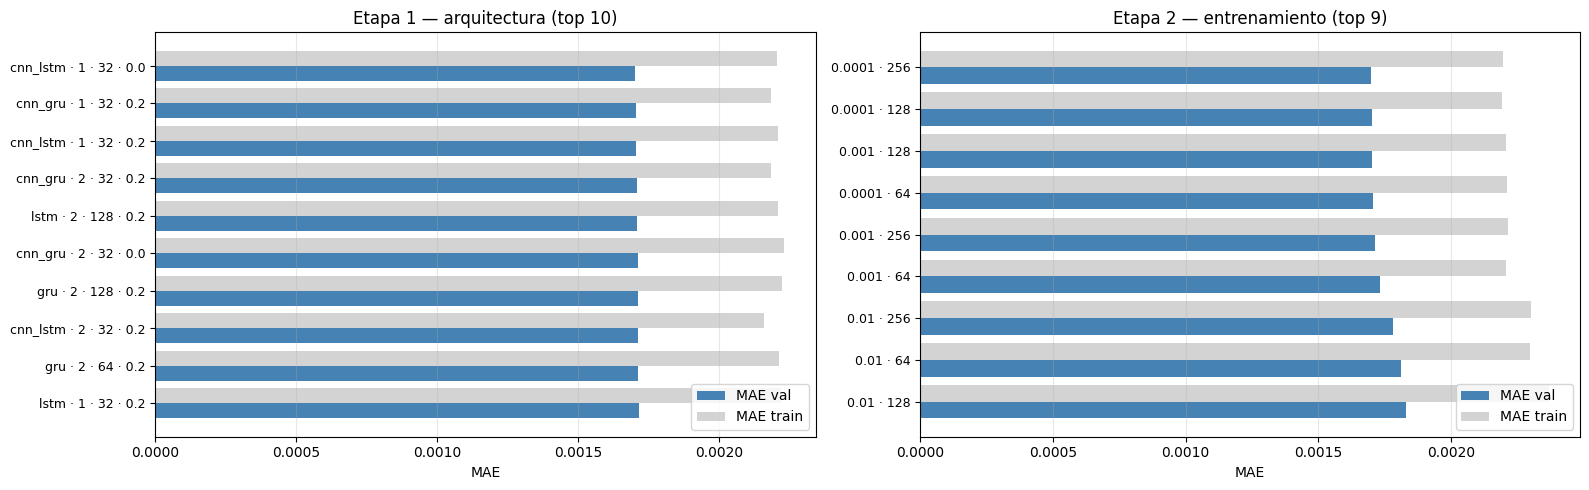

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def plot_top(ax, df, label_cols, title, top=10):
    top_df = df.head(top).iloc[::-1]
    labels = top_df[label_cols].astype(str).agg(" · ".join, axis=1)
    ypos = np.arange(len(top_df))
    ax.barh(ypos - 0.2, top_df["MAE_val"],   height=0.4, label="MAE val",   color="steelblue")
    ax.barh(ypos + 0.2, top_df["MAE_train"], height=0.4, label="MAE train", color="lightgray")
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("MAE")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True, axis="x", alpha=0.3)

plot_top(axes[0], results_arch_df,  ["arch", "n_layers", "units", "dropout"],
         "Etapa 1 — arquitectura (top 10)")
plot_top(axes[1], results_train_df, ["learning_rate", "batch_size"],
         "Etapa 2 — entrenamiento (top 9)")

plt.tight_layout()
plt.show()